In [1]:
import mne
import openneuro
import pandas as pd
import numpy as np
np.set_printoptions(threshold=np.inf)
np.set_printoptions(linewidth=np.inf)
from mne_bids import (
    BIDSPath,
    find_matching_paths,
    get_entity_vals,
    make_report,
    print_dir_tree,
    read_raw_bids,
	write_raw_bids
)

In [2]:
def _channel_mapping(channel_list):
	new_list = []

	for channel in channel_list:
		if channel == "FP1":
			new_list.append("Fp1")
		elif channel == "FP2":
			new_list.append("Fp2")
		elif channel == "CZ":
			new_list.append("Cz")
		else:
			new_list.append(channel)
	return new_list


In [3]:
# From https://github.com/braindecode/braindecode/blob/master/braindecode/datasets/tuh.py
def _rename_channels(raw):
	"""
	Renames the EEG channels using mne conventions and sets their type to 'eeg'.

	See https://isip.piconepress.com/publications/reports/2020/tuh_eeg/electrodes/
	"""
	# remove ref suffix and prefix:
	# TODO: replace with removesuffix and removeprefix when 3.8 is dropped
	mapping_strip = {
		c: c.replace("-REF", "").replace("-LE", "").replace("EEG ", "")
		for c in raw.ch_names
	}
	raw.rename_channels(mapping_strip)

	montage1005 = mne.channels.make_standard_montage("standard_1005")
	mapping_eeg_names = {
		c.upper(): c for c in montage1005.ch_names if c.upper() in raw.ch_names
	}

	# Set channels whose type could not be inferred (defaulted to "eeg") to "misc":
	non_eeg_names = [c for c in raw.ch_names if c not in mapping_eeg_names]
	if non_eeg_names:
		non_eeg_types = raw.get_channel_types(picks=non_eeg_names)
		mapping_non_eeg_types = {
			c: "misc" for c, t in zip(non_eeg_names, non_eeg_types) if t == "eeg"
		}
		if mapping_non_eeg_types:
			raw.set_channel_types(mapping_non_eeg_types)

	if mapping_eeg_names:
		# Set 1005 channels type to "eeg":
		raw.set_channel_types(
			{c: "eeg" for c in mapping_eeg_names}, on_unit_change="ignore"
		)
		# Fix capitalized EEG channel names:
		raw.rename_channels(mapping_eeg_names)

In [32]:
openneuro.download(dataset="ds004186", target_dir="SampleData/HBN-ECEO", include=['NDARAA075AMK'])


👋 Hello! This is openneuro-py 2024.2.0. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/hoechenberger/openneuro-py/issues

🌍 Preparing to download ds004186 …


📁 Traversing directories for ds004186 : 0 entities [00:00, ? entities/s]

RuntimeError: Could not find path in the dataset:
- NDARAA075AMK
There were no similar filenames found in the metadata. Please check your includes.

In [4]:
TUH_patient = mne.io.read_raw_edf('SampleData/TUH/aaaaaaac_s001_t000.edf', preload=False)
_rename_channels(TUH_patient)
print(TUH_patient.info.ch_names)
TUH_patient.info["line_freq"] = 50
annotations_df = pd.read_csv('SampleData/TUH/aaaaaaac_s001_t000.csv', delimiter=',', comment='#')

onset = annotations_df['start_time']
duration = annotations_df['stop_time'] - annotations_df['start_time']
description = annotations_df['label']
ch_names = [_channel_mapping(x.split("-")) for x in annotations_df['channel'].values.tolist()]

global_annotations_df = pd.read_csv('SampleData/TUH/aaaaaaac_s001_t000.csv_bi', delimiter=',', comment='#')

onset = pd.concat([onset, global_annotations_df['start_time']])
duration = pd.concat([duration, global_annotations_df['stop_time'] - global_annotations_df['start_time']])
description = pd.concat([description, global_annotations_df['label']])
global_channel_names = [[] for x in global_annotations_df['channel'].values.tolist()]
ch_names = ch_names + global_channel_names

annotations = mne.Annotations(onset=onset, duration=duration, description=description, ch_names=ch_names)

TUH_patient.set_annotations(annotations)
montage = mne.channels.make_standard_montage("standard_1005")
TUH_patient.set_montage(montage, on_missing="ignore")
for channel in TUH_patient.info["chs"]:
	print(channel['loc'])

Extracting EDF parameters from /mnt/batch/tasks/shared/LS_root/mounts/clusters/mchen439-e8ads-v5/code/Users/mchen439/EEG-Foundation-Model/SampleData/TUH/aaaaaaac_s001_t000.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'A1', 'A2', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz', 'Oz', 'PG1', 'PG2', 'EKG', 'SP2', 'SP1', 'RLC', 'LUC', '30', 'T1', 'T2', 'PHOTIC PH']


/tmp/ipykernel_4161/1918410036.py:29: RuntimeWarning: The unit for channel(s) 30, EKG, LUC, PG1, PG2, PHOTIC PH, RLC, SP1, SP2, T1, T2 has changed from V to NA.
  raw.set_channel_types(mapping_non_eeg_types)


[-0.03090259  0.11458518  0.02786657  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[0.0284095  0.11534631 0.02772126 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[-0.05180904  0.0866879   0.07871409  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[0.05027428 0.08743839 0.07727065 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[-0.06714872  0.02335823  0.10451068  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[0.06532888 0.0235731  0.10369243 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[-0.08794078  0.00260136 -0.02686454  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[ 0.08392806  

In [ ]:
bids_path = BIDSPath(subject="aaaaaaac", task="Rest", root="SampleData/TUH-BIDS")
write_raw_bids(TUH_patient, bids_path, overwrite=True)

In [153]:
hbn_bids_path = BIDSPath(root="SampleData/HBN", session=None, datatype="eeg")
hbn_bids_path = hbn_bids_path.update(subject="NDARAC904DMU", task="RestingState", suffix="eeg")
HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)

/tmp/ipykernel_5929/2368780825.py:3: RuntimeWarning: Data will be preloaded. preload=False or a string preload is not supported when the data is stored in the .set file
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)


Reading events from SampleData/HBN/sub-NDARAC904DMU/eeg/sub-NDARAC904DMU_task-RestingState_events.tsv.
Reading channel info from SampleData/HBN/sub-NDARAC904DMU/eeg/sub-NDARAC904DMU_task-RestingState_channels.tsv.
Reading electrode coords from SampleData/HBN/sub-NDARAC904DMU/eeg/sub-NDARAC904DMU_task-RestingState_electrodes.tsv.


/tmp/ipykernel_5929/2368780825.py:3: RuntimeWarning: Unable to map the following column(s) to to MNE:
release_number: R1
ehq_total: 71.17
commercial_use: Yes
full_pheno: Yes
p_factor: -0.603
attention: -0.446
internalizing: 1.248
externalizing: 0.325
RestingState: available
DespicableMe: available
FunwithFractals: available
ThePresent: available
DiaryOfAWimpyKid: available
contrastChangeDetection_1: available
contrastChangeDetection_2: available
contrastChangeDetection_3: available
surroundSupp_1: available
surroundSupp_2: available
seqLearning6target: unavailable
seqLearning8target: available
symbolSearch: available
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)


In [ ]:
tuh_bids_path = BIDSPath(root="SampleData/TUH-BIDS", session=None, datatype="eeg")
tuh_bids_path = tuh_bids_path.update(subject="aaaaaaac", task="Rest", suffix="eeg")
TUH_patient = read_raw_bids(bids_path=tuh_bids_path, verbose=True)

In [ ]:
TUH_patient.load_data()
TUH_patient.set_eeg_reference(ref_channels=['A1', 'A2'])
print(TUH_patient.info)
TUH_patient.set_eeg_reference(ref_channels=['Cz'])

In [154]:
# See Page 234 of /https://psych.colgate.edu/~bchansen/EGI_GES_INFO/NetStation_Acquisition_Technical_Manual.pdf
electrode_map = {
	'Fp1': 'E22',
	'Fp2': 'E14',
	'F7': 'E34',
	'F3': 'E25',
	'Fz': 'E11',
	'F4': 'E124',
	'F8': 'E122',
	'T3': 'E46',
	'C3': 'E37',
	'Cz': 'Cz',
	'C4': 'E105',
	'T4': 'E109',
	'T5': 'E59',
	'P3': 'E53',
	'Pz': 'E62',
	'P4': 'E87',
	'T6': 'E92',
	'O1': 'E72',
	'O2': 'E77',
	'A1': 'E49',
	'A2': 'E114'
}

electrode_map2 = {
	'Fp1': 'E22',
	'Fp2': 'E9',
	'F7': 'E33',
	'F3': 'E24',
	'Fz': 'E11',
	'F4': 'E124',
	'F8': 'E122',
	'T3': 'E45',
	'C3': 'E36',
	'Cz': 'Cz',
	'C4': 'E104',
	'T4': 'E108',
	'T5': 'E58',
	'P3': 'E52',
	'Pz': 'E62',
	'P4': 'E92',
	'T6': 'E96',
	'O1': 'E70',
	'O2': 'E83',
	'A1': 'E49',
	'A2': 'E113'
}

HBN_ELECTRODE_MAP = {
	'Fp1': 'E22',
	'Fp2': 'E9',
	'F7': 'E33',
	'F3': 'E24',
	'Fz': 'E11',
	'F4': 'E124',
	'F8': 'E122',
	'T3': 'E45',
	'C3': 'E36',
	'Cz': 'Cz',
	'C4': 'E104',
	'T4': 'E108',
	'T5': 'E58',
	'P3': 'E52',
	'Pz': 'E62',
	'P4': 'E92',
	'T6': 'E96',
	'O1': 'E70',
	'O2': 'E83',
}

electrodes = [f'E{i}' for i in range(1, 129)]
to_drop = [electrode for electrode in electrodes if electrode not in HBN_ELECTRODE_MAP.values()]

In [155]:
#TUH_patient = TUH_patient.filter(l_freq=0, h_freq=40)
HBN_patient.drop_channels(to_drop)
HBN_patient = HBN_patient.filter(l_freq=0, h_freq=40)

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 165 samples (0.330 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


In [5]:
TUH_patient.info

NameError: name 'TUH_patient' is not defined

In [126]:
HBN_patient.info

<Info | 10 non-empty values
 bads: []
 ch_names: E9, E11, E22, E24, E33, E36, E45, E52, E58, E62, E70, E83, E92, ...
 chs: 19 EEG
 custom_ref_applied: False
 dig: 129 items (129 EEG)
 highpass: 0.0 Hz
 line_freq: 60.0
 lowpass: 40.0 Hz
 meas_date: unspecified
 nchan: 19
 projs: []
 sfreq: 500.0 Hz
 subject_info: 2 items (dict)
>

In [22]:
TUH_patient.get_montage().plot(show_names=True)

NameError: name 'TUH_patient' is not defined

In [12]:
for channel in HBN_patient.info["chs"]:
	print(channel['loc'])

[ 0.05787678  0.05520863 -0.02577469  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[0.05291805 0.06709098 0.00307435 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[0.03864122 0.07634241 0.0306777  0.         0.         0.                nan        nan        nan        nan        nan        nan]
[0.02868838 0.07145709 0.04989565 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[0.0147934  0.05686621 0.06812878 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[0.         0.0380677  0.07891305 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[-0.012238    0.01558864  0.08440439  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[ 0.04221902  0.07998817 -0.0135479   

In [156]:
ch_pos = {}

for channel in HBN_patient.info["chs"]:
	ch_pos[channel['ch_name']] = channel['loc'][0:3]

print(ch_pos)

montage = mne.channels.make_dig_montage(ch_pos, coord_frame='head')

HBN_patient.set_montage(montage)

{'E9': array([ 0.00888482, -0.00269541,  0.00108831]), 'E11': array([ 0.00796265, -0.        ,  0.00504472]), 'E22': array([0.00888482, 0.00269541, 0.00108831]), 'E24': array([0.00602116, 0.00445939, 0.00436532]), 'E33': array([ 0.00412725,  0.00639909, -0.00035685]), 'E36': array([0.00028495, 0.00547913, 0.00638333]), 'E45': array([-0.00186624,  0.00730462, -0.00062918]), 'E52': array([-0.00449482,  0.00583124,  0.00495535]), 'E58': array([-5.755782e-03,  6.034747e-03,  5.184300e-05]), 'E62': array([-0.00667669, -0.        ,  0.00646521]), 'E70': array([-0.00860797,  0.00273884,  0.00023937]), 'E83': array([-0.00860797, -0.00273884,  0.00023937]), 'E92': array([-0.00449482, -0.00583124,  0.00495535]), 'E96': array([-5.755782e-03, -6.034747e-03,  5.184300e-05]), 'E104': array([ 0.00028495, -0.00547913,  0.00638333]), 'E108': array([-0.00186624, -0.00730462, -0.00062918]), 'E122': array([ 0.00412725, -0.00639909, -0.00035685]), 'E124': array([ 0.00602116, -0.00445939,  0.00436532]), 'Cz

<RawEEGLAB | sub-NDARAC904DMU_task-RestingState_eeg.set, 19 x 201737 (403.5 s), ~29.3 MB, data loaded>

In [171]:
for k, v in HBN_patient.info.items():
	print(k, v)

acq_pars None
acq_stim None
ctf_head_t None
description None
dev_ctf_t None
dig [<DigPoint |        LPA : (-8.6, 0.0, 0.0) mm       : head frame>, <DigPoint |     Nasion : (0.0, 8.6, 0.0) mm        : head frame>, <DigPoint |        RPA : (8.6, 0.0, 0.0) mm        : head frame>, <DigPoint |     EEG #1 : (8.9, -2.7, 1.1) mm       : head frame>, <DigPoint |     EEG #2 : (8.0, -0.0, 5.0) mm       : head frame>, <DigPoint |     EEG #3 : (8.9, 2.7, 1.1) mm        : head frame>, <DigPoint |     EEG #4 : (6.0, 4.5, 4.4) mm        : head frame>, <DigPoint |     EEG #5 : (4.1, 6.4, -0.4) mm       : head frame>, <DigPoint |     EEG #6 : (0.3, 5.5, 6.4) mm        : head frame>, <DigPoint |     EEG #7 : (-1.9, 7.3, -0.6) mm      : head frame>, <DigPoint |     EEG #8 : (-4.5, 5.8, 5.0) mm       : head frame>, <DigPoint |     EEG #9 : (-5.8, 6.0, 0.1) mm       : head frame>, <DigPoint |    EEG #10 : (-6.7, -0.0, 6.5) mm      : head frame>, <DigPoint |    EEG #11 : (-8.6, 2.7, 0.2) mm       : head fra

<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 19 channels>
{'ch_pos': OrderedDict([('E9', array([ 0.0888482 , -0.02695406,  0.01088308])), ('E11', array([0.07962647, 0.        , 0.05044718])), ('E22', array([0.0888482 , 0.02695406, 0.01088308])), ('E24', array([0.0602116 , 0.04459387, 0.04365321])), ('E33', array([ 0.04127249,  0.06399087, -0.00356852])), ('E36', array([0.00284949, 0.0547913 , 0.06383328])), ('E45', array([-0.01866238,  0.07304625, -0.00629182])), ('E52', array([-0.04494822,  0.05831241,  0.04955348])), ('E58', array([-0.05755782,  0.06034747,  0.00051843])), ('E62', array([-0.06676694,  0.        ,  0.06465208])), ('E70', array([-0.08607967,  0.02738838,  0.00239368])), ('E83', array([-0.08607967, -0.02738838,  0.00239368])), ('E92', array([-0.04494822, -0.05831241,  0.04955348])), ('E96', array([-0.05755782, -0.06034747,  0.00051843])), ('E104', array([ 0.00284949, -0.0547913 ,  0.06383328])), ('E108', array([-0.01866238, -0.07304625, -0.00629182])), ('E12

/tmp/ipykernel_5929/470286117.py:19: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  hbn_montage.plot(show_names=True, sphere=0.095)


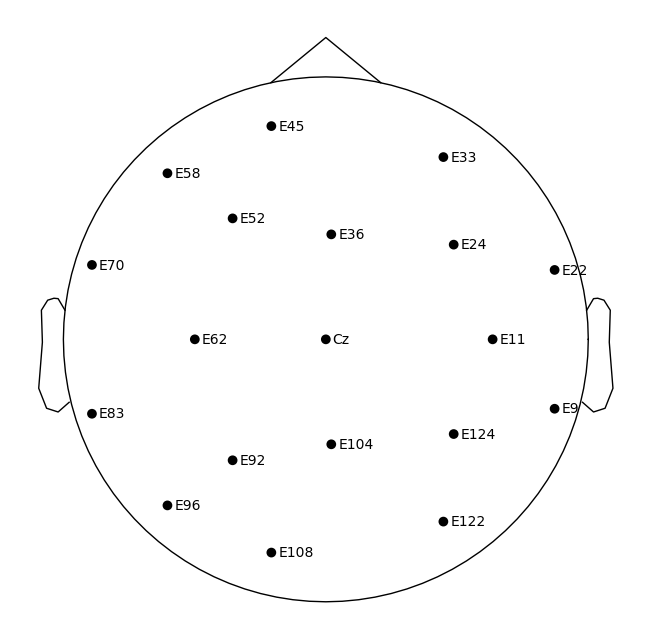

{'ch_pos': OrderedDict([('E9', array([0.02695406, 0.0888482 , 0.01088308])), ('E11', array([0.        , 0.07962647, 0.05044718])), ('E22', array([-0.02695406,  0.0888482 ,  0.01088308])), ('E24', array([-0.04459387,  0.0602116 ,  0.04365321])), ('E33', array([-0.06399087,  0.04127249, -0.00356852])), ('E36', array([-0.0547913 ,  0.00284949,  0.06383328])), ('E45', array([-0.07304625, -0.01866238, -0.00629182])), ('E52', array([-0.05831241, -0.04494822,  0.04955348])), ('E58', array([-0.06034747, -0.05755782,  0.00051843])), ('E62', array([ 0.        , -0.06676694,  0.06465208])), ('E70', array([-0.02738838, -0.08607967,  0.00239368])), ('E83', array([ 0.02738838, -0.08607967,  0.00239368])), ('E92', array([ 0.05831241, -0.04494822,  0.04955348])), ('E96', array([ 0.06034747, -0.05755782,  0.00051843])), ('E104', array([0.0547913 , 0.00284949, 0.06383328])), ('E108', array([ 0.07304625, -0.01866238, -0.00629182])), ('E122', array([ 0.06399087,  0.04127249, -0.00356852])), ('E124', array

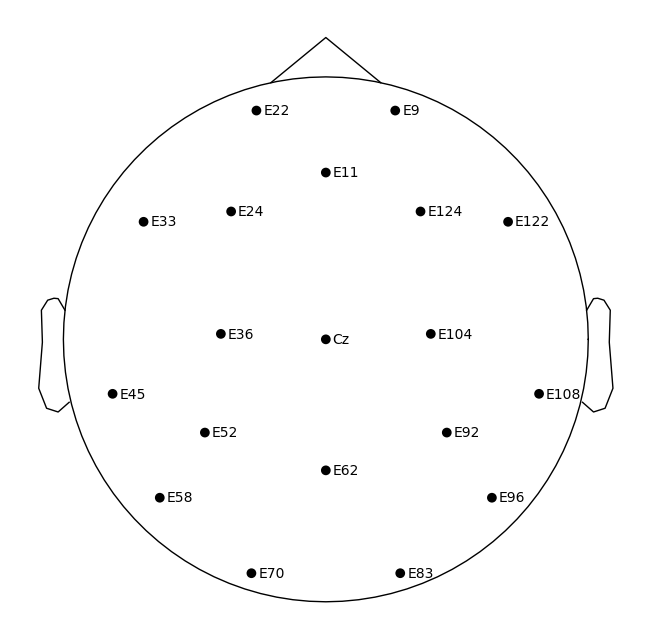

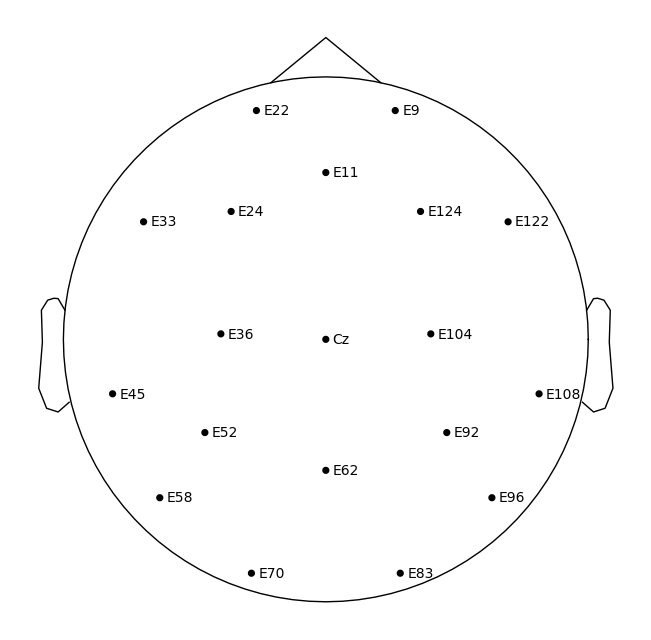

In [192]:
# Define the transformation matrix for 90 degrees counterclockwise rotation
transformation_matrix = np.array([[0, -1, 0, 0],
								  [1, 0, 0, 0],
								  [0, 0, 1, 0],
								  [0, 0, 0, 1]])

transformation_matrix2 = np.array([[10, 0, 0, 0],
								  [0, 10, 0, 0],
								  [0, 0, 10, 0],
								  [0, 0, 0, 10]])


# Get the current montage
hbn_montage = HBN_patient.get_montage()
hbn_montage.apply_trans(mne.transforms.Transform(fro='head', to='unknown', trans=transformation_matrix2))
print(hbn_montage)
print(hbn_montage.get_positions())
hbn_montage.remove_fiducials()
hbn_montage.plot(show_names=True, sphere=0.095)
# Apply the transformation
hbn_montage.apply_trans(mne.transforms.Transform(fro='unknown', to='head', trans=transformation_matrix))

# Print the new positions
print(hbn_montage.get_positions())

# Plot the new montage
hbn_montage.plot(show_names=True, sphere=0.095)

# Undo fiducial transformation

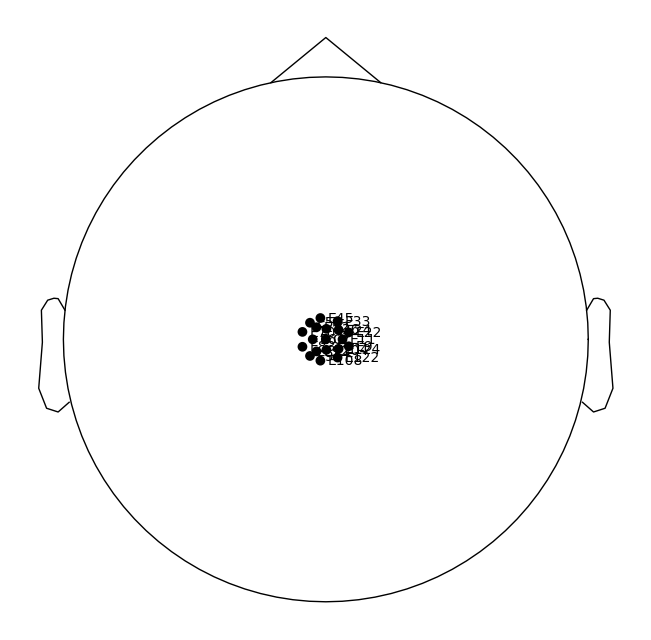

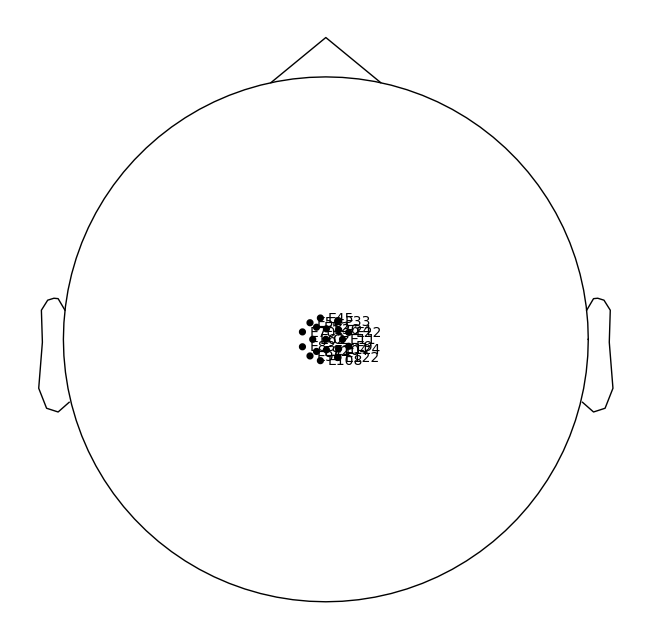

In [178]:
HBN_patient.get_montage().plot(show_names=True)

{'ch_pos': OrderedDict([('E9', array([ 0.00888482, -0.00269541,  0.00108831])), ('E11', array([ 0.00796265, -0.        ,  0.00504472])), ('E22', array([0.00888482, 0.00269541, 0.00108831])), ('E24', array([0.00602116, 0.00445939, 0.00436532])), ('E33', array([ 0.00412725,  0.00639909, -0.00035685])), ('E36', array([0.00028495, 0.00547913, 0.00638333])), ('E45', array([-0.00186624,  0.00730462, -0.00062918])), ('E52', array([-0.00449482,  0.00583124,  0.00495535])), ('E58', array([-5.755782e-03,  6.034747e-03,  5.184300e-05])), ('E62', array([-0.00667669, -0.        ,  0.00646521])), ('E70', array([-0.00860797,  0.00273884,  0.00023937])), ('E83', array([-0.00860797, -0.00273884,  0.00023937])), ('E92', array([-0.00449482, -0.00583124,  0.00495535])), ('E96', array([-5.755782e-03, -6.034747e-03,  5.184300e-05])), ('E104', array([ 0.00028495, -0.00547913,  0.00638333])), ('E108', array([-0.00186624, -0.00730462, -0.00062918])), ('E122', array([ 0.00412725, -0.00639909, -0.00035685])), ('

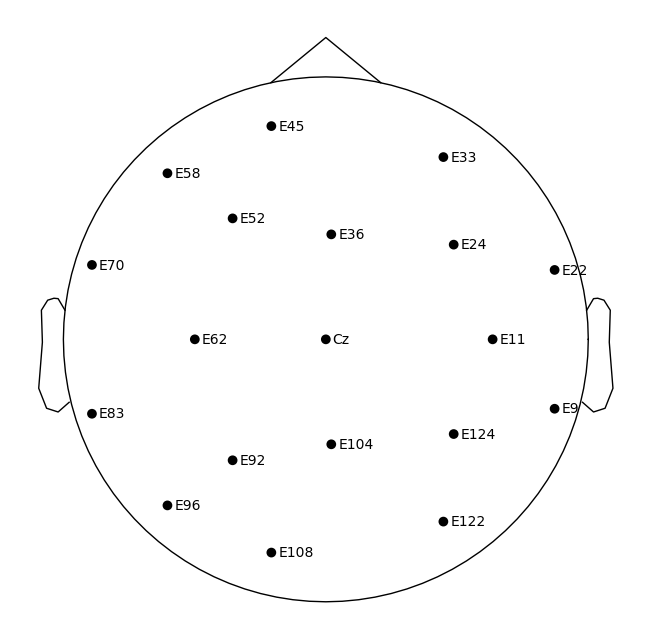

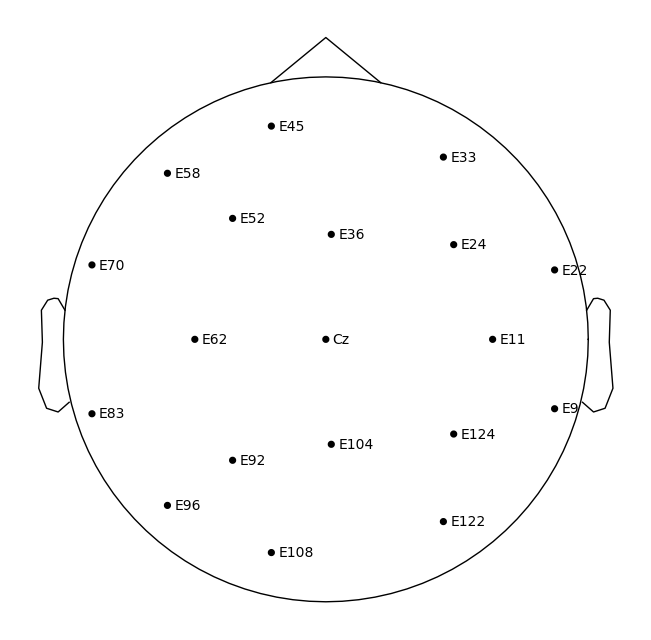

In [175]:
transformation_matrix = np.asarray([[0, -10, 0, 0], [10, 0, 0, 0], [0, 0, 10, 0], [0, 0, 0, 1]])
hbn_montage = HBN_patient.get_montage()
print(hbn_montage.get_positions())
hbn_montage.apply_trans(mne.transforms.Transform(fro='head', to='unknown', trans=transformation_matrix))
print(hbn_montage.get_positions())
hbn_montage.plot(show_names=True, sphere=0.095)

Using matplotlib as 2D backend.


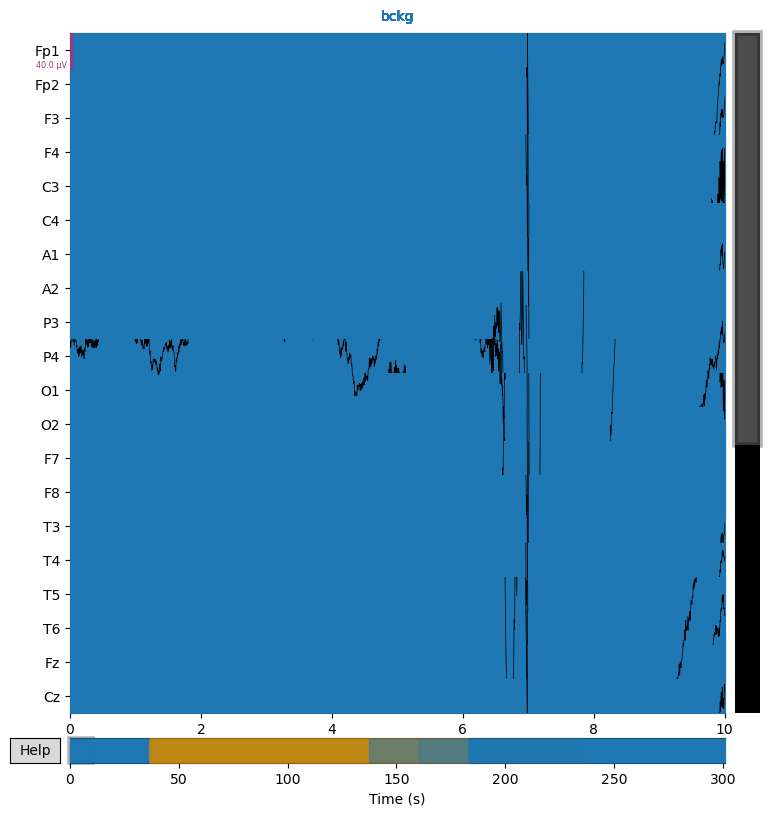

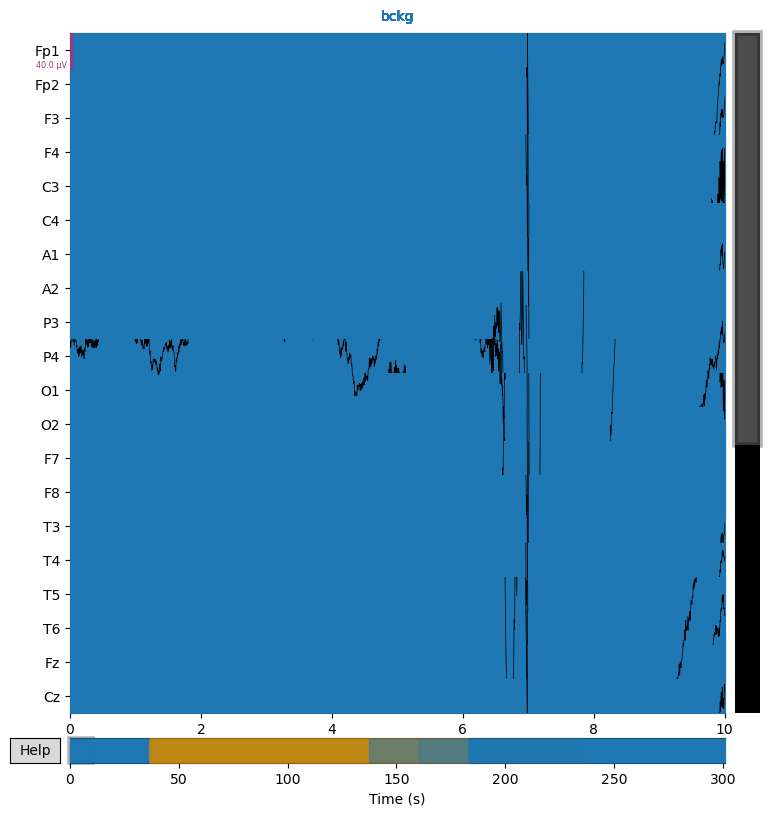

In [9]:
mne.viz.set_browser_backend("matplotlib")
TUH_patient.plot()

In [ ]:
print(TUH_patient.annotations)

In [9]:
TUH_patient = mne.io.read_raw_edf('/home/azureuser/mycontainer/edf/000/aaaaaaaa/s001_2015/01_tcp_ar/aaaaaaaa_s001_t000.edf', preload=False)
TUH_patient.info

Extracting EDF parameters from /home/azureuser/mycontainer/edf/000/aaaaaaaa/s001_2015/01_tcp_ar/aaaaaaaa_s001_t000.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


<Info | 8 non-empty values
 bads: []
 ch_names: EEG FP1-REF, EEG FP2-REF, EEG F3-REF, EEG F4-REF, EEG C3-REF, ...
 chs: 31 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2015-01-01 00:00:00 UTC
 nchan: 31
 projs: []
 sfreq: 256.0 Hz
 subject_info: 3 items (dict)
>

In [13]:
print(TUH_patient.info['meas_date'])
print(TUH_patient.annotations)
print(TUH_patient.get_montage())
print(TUH_patient._raw_extras[0]['age'])

2015-01-01 00:00:00+00:00
<Annotations | 0 segments>
None


KeyError: 'age'

In [14]:
from edfio import read_edf


edf = read_edf('/home/azureuser/mycontainer/edf/000/aaaaaaaa/s001_2015/01_tcp_ar/aaaaaaaa_s001_t000.edf')


In [18]:
print(edf.patient)
print(edf.recording)

'aaaaaaaa M 01-JAN-0000 aaaaaaaa Age:37'
Recording(startdate=datetime.date(2015, 1, 1), hospital_administration_code='aaaaaaaa_s001', investigator_technician_code='XXX', equipment_code='#', additional=())


In [1]:
import os
from tqdm import tqdm
import mne
from mne_bids import BIDSPath, read_raw_bids, write_raw_bids
import pandas as pd
import numpy as np
import os, argparse
from pathlib import Path
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
import warnings


CHANNELS_TO_KEEP = {
	"Fp1",
	"Fp2",
	"F3",
	"F4",
	"C3",
	"C4",
	"A1",
	"A2",
	"P3",
	"P4",
	"O1",
	"O2",
	"F7",
	"F8",
	"T3",
	"T4",
	"T5",
	"T6",
	"Fz",
	"Cz",
	"Pz",
}

print(len(CHANNELS_TO_KEEP))
def process_file(args, subfolder, subject, session, montage_layout, file_token, failed_files):
        if file_token.endswith(".edf"):
            _convertEDFtoBIDS(args, subfolder, subject, session, montage_layout, file_token, failed_files)
        else:
            print("-----------------------------------", file_token)

def convertTUHtoBIDS(args):
	'''
	Converts TUH EEG data to BIDS format.
	'''

	# Collect all files to be processed
	files_to_process = []
	for subfolder in tqdm(os.listdir(args.input_dir)):
		for subject in os.listdir(os.path.join(args.input_dir, subfolder)):
			subject_dir = os.path.join(args.input_dir, subfolder, subject)
			for session in os.listdir(subject_dir):
				for montage_layout in os.listdir(os.path.join(subject_dir, session)):
					for file_token in os.listdir(os.path.join(subject_dir, session, montage_layout)):
						files_to_process.append((args, subfolder, subject, session, montage_layout, file_token))
                            
	return files_to_process
                            
    
def _convertEDFtoBIDS(args, subfolder, subject, session, montage_layout, file_token, failed_files):
	'''
	Converts an EDF file to BIDS format.
	'''
	filepath = os.path.join(args.input_dir, subfolder, subject, session, montage_layout, file_token)
	raw = mne.io.read_raw_edf(filepath, preload=False, verbose=False)
	_rename_channels(raw)

	to_drop = [ch for ch in raw.ch_names if ch not in CHANNELS_TO_KEEP]

	try:
		raw.drop_channels(to_drop)
	except ValueError as e:
		failed_files.append((subject, session, montage_layout, file_token))
		return

	'''
	BIDS Format requires line frequency to be specified.
	Line frequency is the frequency of the power line in the country where the data was recorded.
	For the United States, the line frequency is (typically) 60 Hz.	
	'''
	raw.info["line_freq"] = 60
	raw.set_montage("standard_1005", on_missing="ignore")
	try: 
		assert len(raw.info["ch_names"]) == 21 or len(raw.info["ch_names"]) == 19, f"Expected 19 or 21 channels, got {len(raw.info['ch_names'])} channels."
	except AssertionError as e:
		failed_files.append((subject, session, montage_layout, file_token))
		return
		
	'''
	bids_path = BIDSPath(subject=subject, session=session.replace("_", ""), processing=montage_layout.replace("_", ""),
					     recording=file_token[:-4].split("_")[-1], task="Rest", root=args.output_dir)
                              
    '''
     
# From https://github.com/braindecode/braindecode/blob/master/braindecode/datasets/tuh.py
def _rename_channels(raw):
	"""
	Renames the EEG channels using mne conventions and sets their type to 'eeg'.

	See https://isip.piconepress.com/publications/reports/2020/tuh_eeg/electrodes/
	"""
	# remove ref suffix and prefix:
	# TODO: replace with removesuffix and removeprefix when 3.8 is dropped
	mapping_strip = {
		c: c.replace("-REF", "").replace("-LE", "").replace("EEG ", "")
		for c in raw.ch_names
	}
	raw.rename_channels(mapping_strip)

	montage1005 = mne.channels.make_standard_montage("standard_1005")

	# Changed this line
	mapping_eeg_names = {
		c.upper(): c for c in montage1005.ch_names if c.upper() in raw.ch_names
	}

	# Set channels whose type could not be inferred (defaulted to "eeg") to "misc":
	non_eeg_names = [c for c in raw.ch_names if c not in mapping_eeg_names]
	if non_eeg_names:
		non_eeg_types = raw.get_channel_types(picks=non_eeg_names)
		mapping_non_eeg_types = {
			c: "misc" for c, t in zip(non_eeg_names, non_eeg_types) if t == "eeg"
		}
		if mapping_non_eeg_types:
			raw.set_channel_types(mapping_non_eeg_types)

	if mapping_eeg_names:
		# Set 1005 channels type to "eeg":
		raw.set_channel_types(
			{c: "eeg" for c in mapping_eeg_names}, on_unit_change="ignore"
		)
		# Fix capitalized EEG channel names:
		raw.rename_channels(mapping_eeg_names)
            
# Ignore a specific warning category
warnings.filterwarnings("ignore", category=RuntimeWarning, module="mne")


21


In [2]:
parser = argparse.ArgumentParser()

default_output_dir = "/home/azureuser/mycontainer/TUH-BIDS"
parser.add_argument(
	"--input_dir", type=str, help="Input directory", default="/home/azureuser/mycontainer/edf"
)
parser.add_argument(
	"--output_dir", type=str, help="Output directory", default=default_output_dir
)

#Path(default_output_dir).mkdir(parents=True, exist_ok=True)

args, unknown = parser.parse_known_args()
files_to_process = convertTUHtoBIDS(args)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 151/151 [09:37<00:00,  3.83s/it]


In [4]:
print(f"Processing {len(files_to_process)} files...")

Processing 69652 files...


In [8]:
print(files_to_process[29084 - 1])

(Namespace(input_dir='/home/azureuser/mycontainer/edf', output_dir='/home/azureuser/mycontainer/TUH-BIDS'), '082', 'aaaaamhd', 's009_2015', '01_tcp_ar', 'aaaaamhd_s009_t007.edf')


In [4]:

failed_files = []

In [ ]:
30591

In [42]:
for idx in tqdm(range(30580, 30599)):
	process_file(*files_to_process[idx], failed_files)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:09<00:00,  1.94it/s]


In [5]:
from concurrent.futures import ThreadPoolExecutor

with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_file, *file_args, failed_files) for file_args in files_to_process[39184:]]
    for future in tqdm(as_completed(futures), total=len(futures)):
        future.result()  # To raise exceptions if any

Setting channel info structure...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30468/30468 [31:02<00:00, 16.36it/s]


In [6]:
print(len(failed_files))
print(failed_files)

25
[('aaaaapks', 's013_2014', '03_tcp_ar_a', 'aaaaapks_s013_t002.edf'), ('aaaaaqzw', 's002_2014', '01_tcp_ar', 'aaaaaqzw_s002_t001.edf'), ('aaaaaria', 's001_2014', '01_tcp_ar', 'aaaaaria_s001_t000.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t001.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t004.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t002.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t003.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t005.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t006.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t007.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t010.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t012.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t011.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t009.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaar

In [7]:
pd.DataFrame(failed_files, columns=["subject", "session", "montage_layout", "file_token"]).to_csv("failed_files_2.csv", index=False)

In [35]:
hbn_bids_path = BIDSPath(root="SampleData/HBN-ECEO", session=None, datatype="eeg")
hbn_bids_path = hbn_bids_path.update(subject="NDARZZ993CEV", task="EC", run=1, suffix="eeg")
HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)

Reading /mnt/batch/tasks/shared/LS_root/mounts/clusters/mchen439-e8ads-v5/code/Users/mchen439/EEG-Foundation-Model/SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EC_run-1_eeg.fdt
Reading channel info from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EC_run-1_channels.tsv.


/tmp/ipykernel_5929/2551377497.py:3: RuntimeWarning: Did not find any events.tsv associated with sub-NDARZZ993CEV_task-EC_run-1.

The search_str was "SampleData/HBN-ECEO/sub-NDARZZ993CEV/**/eeg/sub-NDARZZ993CEV*events.tsv"
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2551377497.py:3: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E1" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2551377497.py:3: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E2" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2551377497.py:3: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E3" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2551377497.py:3: RuntimeWarning

Reading electrode coords from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EC_run-1_electrodes.tsv.


/tmp/ipykernel_5929/2551377497.py:3: RuntimeWarning: Not setting positions of 129 misc channels found in montage:
['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30', 'E31', 'E32', 'E33', 'E34', 'E35', 'E36', 'E37', 'E38', 'E39', 'E40', 'E41', 'E42', 'E43', 'E44', 'E45', 'E46', 'E47', 'E48', 'E49', 'E50', 'E51', 'E52', 'E53', 'E54', 'E55', 'E56', 'E57', 'E58', 'E59', 'E60', 'E61', 'E62', 'E63', 'E64', 'E65', 'E66', 'E67', 'E68', 'E69', 'E70', 'E71', 'E72', 'E73', 'E74', 'E75', 'E76', 'E77', 'E78', 'E79', 'E80', 'E81', 'E82', 'E83', 'E84', 'E85', 'E86', 'E87', 'E88', 'E89', 'E90', 'E91', 'E92', 'E93', 'E94', 'E95', 'E96', 'E97', 'E98', 'E99', 'E100', 'E101', 'E102', 'E103', 'E104', 'E105', 'E106', 'E107', 'E108', 'E109', 'E110', 'E111', 'E112', 'E113', 'E114', 'E115', 'E116', 'E117', 'E118', 'E119', 'E120', 'E121', 'E122', 'E123', 'E124', '

In [43]:
HBN_patient.info

ch_pos = {}

for channel in HBN_patient.info["chs"]:
	ch_pos[channel['ch_name']] = channel['loc'][0:3]

montage = mne.channels.make_dig_montage(ch_pos=ch_pos, coord_frame='head')
print(montage)

<DigMontage | 0 extras (headshape), 0 HPIs, 0 fiducials, 129 channels>


In [37]:
montage = HBN_patient.get_montage()
print(montage)

<DigMontage | 0 extras (headshape), 0 HPIs, 0 fiducials, 0 channels>


In [7]:
print(HBN_patient.n_times, HBN_patient.info['sfreq'], HBN_patient.get_data().shape, HBN_patient.get_data().shape[1] / HBN_patient.info['sfreq'])

19998 500.0 (129, 19998) 39.996


In [57]:
HBN_patient_runs = []
for run in range(1, 6):
	hbn_bids_path = BIDSPath(root="SampleData/HBN-ECEO", session=None, datatype="eeg")
	hbn_bids_path = hbn_bids_path.update(subject="NDARZZ993CEV", task="EO", run=run, suffix="eeg")
	HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
	HBN_patient_runs.append(HBN_patient)

HBN_EC = mne.concatenate_raws(HBN_patient_runs)

print(HBN_EC.n_times, HBN_EC.info['sfreq'], HBN_EC.get_data().shape, HBN_EC.get_data().shape[1] / HBN_EC.info['sfreq'])



Reading /mnt/batch/tasks/shared/LS_root/mounts/clusters/mchen439-e8ads-v5/code/Users/mchen439/EEG-Foundation-Model/SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-1_eeg.fdt
Reading channel info from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-1_channels.tsv.
Reading electrode coords from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-1_electrodes.tsv.


/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: Did not find any events.tsv associated with sub-NDARZZ993CEV_task-EO_run-1.

The search_str was "SampleData/HBN-ECEO/sub-NDARZZ993CEV/**/eeg/sub-NDARZZ993CEV*events.tsv"
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E1" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E2" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E3" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning

Reading /mnt/batch/tasks/shared/LS_root/mounts/clusters/mchen439-e8ads-v5/code/Users/mchen439/EEG-Foundation-Model/SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-2_eeg.fdt


/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: Not setting positions of 129 misc channels found in montage:
['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30', 'E31', 'E32', 'E33', 'E34', 'E35', 'E36', 'E37', 'E38', 'E39', 'E40', 'E41', 'E42', 'E43', 'E44', 'E45', 'E46', 'E47', 'E48', 'E49', 'E50', 'E51', 'E52', 'E53', 'E54', 'E55', 'E56', 'E57', 'E58', 'E59', 'E60', 'E61', 'E62', 'E63', 'E64', 'E65', 'E66', 'E67', 'E68', 'E69', 'E70', 'E71', 'E72', 'E73', 'E74', 'E75', 'E76', 'E77', 'E78', 'E79', 'E80', 'E81', 'E82', 'E83', 'E84', 'E85', 'E86', 'E87', 'E88', 'E89', 'E90', 'E91', 'E92', 'E93', 'E94', 'E95', 'E96', 'E97', 'E98', 'E99', 'E100', 'E101', 'E102', 'E103', 'E104', 'E105', 'E106', 'E107', 'E108', 'E109', 'E110', 'E111', 'E112', 'E113', 'E114', 'E115', 'E116', 'E117', 'E118', 'E119', 'E120', 'E121', 'E122', 'E123', 'E124', '

Reading channel info from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-2_channels.tsv.


...

Reading electrode coords from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-4_electrodes.tsv.
Reading /mnt/batch/tasks/shared/LS_root/mounts/clusters/mchen439-e8ads-v5/code/Users/mchen439/EEG-Foundation-Model/SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-5_eeg.fdt


/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: Not setting positions of 129 misc channels found in montage:
['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30', 'E31', 'E32', 'E33', 'E34', 'E35', 'E36', 'E37', 'E38', 'E39', 'E40', 'E41', 'E42', 'E43', 'E44', 'E45', 'E46', 'E47', 'E48', 'E49', 'E50', 'E51', 'E52', 'E53', 'E54', 'E55', 'E56', 'E57', 'E58', 'E59', 'E60', 'E61', 'E62', 'E63', 'E64', 'E65', 'E66', 'E67', 'E68', 'E69', 'E70', 'E71', 'E72', 'E73', 'E74', 'E75', 'E76', 'E77', 'E78', 'E79', 'E80', 'E81', 'E82', 'E83', 'E84', 'E85', 'E86', 'E87', 'E88', 'E89', 'E90', 'E91', 'E92', 'E93', 'E94', 'E95', 'E96', 'E97', 'E98', 'E99', 'E100', 'E101', 'E102', 'E103', 'E104', 'E105', 'E106', 'E107', 'E108', 'E109', 'E110', 'E111', 'E112', 'E113', 'E114', 'E115', 'E116', 'E117', 'E118', 'E119', 'E120', 'E121', 'E122', 'E123', 'E124', '

Reading channel info from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-5_channels.tsv.
Reading electrode coords from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-5_electrodes.tsv.


/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E1" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E2" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E3" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E4" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/2825096335.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E

49990 500.0 (129, 49990) 99.98


In [4]:
HBN_ELECTRODE_MAP = {
	'Fp1': 'E22',
	'Fp2': 'E9',
	'F7': 'E33',
	'F3': 'E24',
	'Fz': 'E11',
	'F4': 'E124',
	'F8': 'E122',
	'T3': 'E45',
	'C3': 'E36',
	'Cz': 'Cz',
	'C4': 'E104',
	'T4': 'E108',
	'T5': 'E58',
	'P3': 'E52',
	'Pz': 'E62',
	'P4': 'E92',
	'T6': 'E96',
	'O1': 'E70',
	'O2': 'E83',
}

electrodes = [f'E{i}' for i in range(1, 129)]
to_drop = [electrode for electrode in electrodes if electrode not in HBN_ELECTRODE_MAP.values()]
HBN_EC.drop_channels(to_drop)

NameError: name 'HBN_EC' is not defined

In [61]:
ch_pos = {}

for channel in HBN_EC.info["chs"]:
	ch_pos[channel['ch_name']] = channel['loc'][0:3]

montage = mne.channels.make_dig_montage(ch_pos=ch_pos, coord_frame='head')

print(ch_pos)

{'E9': array([0.02695406, 0.0888482 , 0.01088308]), 'E11': array([0.        , 0.07962647, 0.05044718]), 'E22': array([-0.02695406,  0.0888482 ,  0.01088308]), 'E24': array([-0.04459387,  0.0602116 ,  0.04365321]), 'E33': array([-0.06399087,  0.04127249, -0.00356852]), 'E36': array([-0.0547913 ,  0.00284949,  0.06383328]), 'E45': array([-0.07304625, -0.01866238, -0.00629182]), 'E52': array([-0.05831241, -0.04494822,  0.04955348]), 'E58': array([-0.06034747, -0.05755782,  0.00051843]), 'E62': array([ 8.17659198e-18, -6.67669403e-02,  6.46520826e-02]), 'E70': array([-0.02738838, -0.08607967,  0.00239368]), 'E83': array([ 0.02738838, -0.08607967,  0.00239368]), 'E92': array([ 0.05831241, -0.04494822,  0.04955348]), 'E96': array([ 0.06034747, -0.05755782,  0.00051843]), 'E104': array([0.0547913 , 0.00284949, 0.06383328]), 'E108': array([ 0.07304625, -0.01866238, -0.00629182]), 'E122': array([ 0.06399087,  0.04127249, -0.00356852]), 'E124': array([0.04459387, 0.0602116 , 0.04365321]), 'Cz': 

In [63]:
# Set all channels to be EEG channels
mapping = {ch: 'eeg' for ch in HBN_EC.ch_names}
HBN_EC.set_channel_types(mapping)

/tmp/ipykernel_5929/2200048278.py:3: RuntimeWarning: The unit for channel(s) Cz, E104, E108, E11, E122, E124, E22, E24, E33, E36, E45, E52, E58, E62, E70, E83, E9, E92, E96 has changed from NA to V.
  HBN_EC.set_channel_types(mapping)


<RawEEGLAB | sub-NDARZZ993CEV_task-EO_run-1_eeg.fdt, 19 x 49990 (100.0 s), ~25 kB, data not loaded>

In [64]:
HBN_EC.set_montage(montage, match_case=False)

<RawEEGLAB | sub-NDARZZ993CEV_task-EO_run-1_eeg.fdt, 19 x 49990 (100.0 s), ~33 kB, data not loaded>

In [65]:
for channel in HBN_EC.info["chs"]:
	print(channel['loc'])

[0.02695406 0.0888482  0.01088308 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[0.         0.07962647 0.05044718 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[-0.02695406  0.0888482   0.01088308  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[-0.04459387  0.0602116   0.04365321  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[-0.06399087  0.04127249 -0.00356852  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[-0.0547913   0.00284949  0.06383328  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[-0.07304625 -0.01866238 -0.00629182  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[-

In [66]:
HBN_EC.set_montage(montage)

<RawEEGLAB | sub-NDARZZ993CEV_task-EO_run-1_eeg.fdt, 19 x 49990 (100.0 s), ~33 kB, data not loaded>

<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 19 channels>
{'ch_pos': OrderedDict([('E9', array([-0.0888482 ,  0.02695406,  0.01088308])), ('E11', array([-0.07962647,  0.        ,  0.05044718])), ('E22', array([-0.0888482 , -0.02695406,  0.01088308])), ('E24', array([-0.0602116 , -0.04459387,  0.04365321])), ('E33', array([-0.04127249, -0.06399087, -0.00356852])), ('E36', array([-0.00284949, -0.0547913 ,  0.06383328])), ('E45', array([ 0.01866238, -0.07304625, -0.00629182])), ('E52', array([ 0.04494822, -0.05831241,  0.04955348])), ('E58', array([ 0.05755782, -0.06034747,  0.00051843])), ('E62', array([6.67669403e-02, 8.17659198e-18, 6.46520826e-02])), ('E70', array([ 0.08607967, -0.02738838,  0.00239368])), ('E83', array([0.08607967, 0.02738838, 0.00239368])), ('E92', array([0.04494822, 0.05831241, 0.04955348])), ('E96', array([0.05755782, 0.06034747, 0.00051843])), ('E104', array([-0.00284949,  0.0547913 ,  0.06383328])), ('E108', array([ 0.01866238,  0.07304625, -0.006291

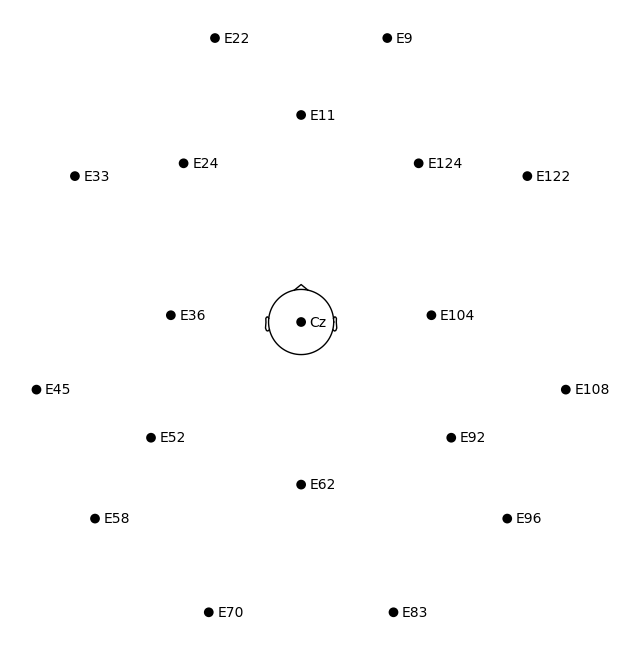

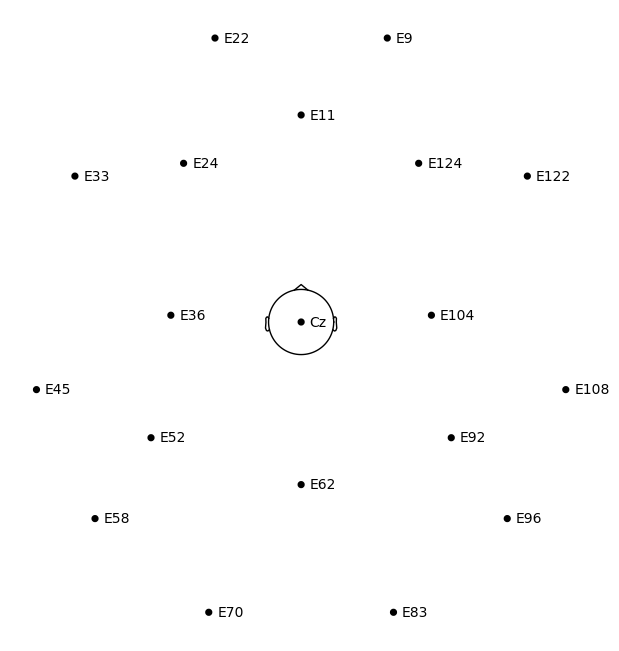

In [67]:
transformation_matrix = np.asarray([[0, -1, 0, 0], [1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])
hbn_montage = HBN_EC.get_montage()
print(HBN_EC.get_montage())
hbn_montage.apply_trans(mne.transforms.Transform(fro='head', to='unknown', trans=transformation_matrix))
print(hbn_montage.get_positions())
hbn_montage.plot(show_names=True, sphere=0.0095)

In [115]:
HBN_patient_runs = []
for run in range(1, 6):
	hbn_bids_path = BIDSPath(root="SampleData/HBN-ECEO", session=None, datatype="eeg")
	hbn_bids_path = hbn_bids_path.update(subject="NDARZZ993CEV", task="EO", run=run, suffix="eeg")
	HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
	HBN_patient_runs.append(HBN_patient)

HBN_EC = mne.concatenate_raws(HBN_patient_runs)

# Set all channels to be EEG channels
mapping = {ch: 'eeg' for ch in HBN_EC.ch_names}
HBN_EC.set_channel_types(mapping)

Reading /mnt/batch/tasks/shared/LS_root/mounts/clusters/mchen439-e8ads-v5/code/Users/mchen439/EEG-Foundation-Model/SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-1_eeg.fdt
Reading channel info from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-1_channels.tsv.
Reading electrode coords from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-1_electrodes.tsv.


/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: Did not find any events.tsv associated with sub-NDARZZ993CEV_task-EO_run-1.

The search_str was "SampleData/HBN-ECEO/sub-NDARZZ993CEV/**/eeg/sub-NDARZZ993CEV*events.tsv"
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E1" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E2" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E3" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning

Reading /mnt/batch/tasks/shared/LS_root/mounts/clusters/mchen439-e8ads-v5/code/Users/mchen439/EEG-Foundation-Model/SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-2_eeg.fdt
Reading channel info from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-2_channels.tsv.


/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: Unable to map the following column(s) to to MNE:
release: 9
gender: 1
handedness: -73.3400000000
commercial_use: Yes
full_pheno: Yes
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: Did not find any events.tsv associated with sub-NDARZZ993CEV_task-EO_run-2.

The search_str was "SampleData/HBN-ECEO/sub-NDARZZ993CEV/**/eeg/sub-NDARZZ993CEV*events.tsv"
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E1" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E2" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_

Reading electrode coords from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-2_electrodes.tsv.
Reading /mnt/batch/tasks/shared/LS_root/mounts/clusters/mchen439-e8ads-v5/code/Users/mchen439/EEG-Foundation-Model/SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-3_eeg.fdt


...

Reading /mnt/batch/tasks/shared/LS_root/mounts/clusters/mchen439-e8ads-v5/code/Users/mchen439/EEG-Foundation-Model/SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-5_eeg.fdt
Reading channel info from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-5_channels.tsv.


/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: Unable to map the following column(s) to to MNE:
release: 9
gender: 1
handedness: -73.3400000000
commercial_use: Yes
full_pheno: Yes
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: Did not find any events.tsv associated with sub-NDARZZ993CEV_task-EO_run-5.

The search_str was "SampleData/HBN-ECEO/sub-NDARZZ993CEV/**/eeg/sub-NDARZZ993CEV*events.tsv"
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E1" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "E2" will be set to "misc".
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)
/tmp/ipykernel_

Reading electrode coords from SampleData/HBN-ECEO/sub-NDARZZ993CEV/eeg/sub-NDARZZ993CEV_task-EO_run-5_electrodes.tsv.


/tmp/ipykernel_5929/3843647923.py:5: RuntimeWarning: Not setting positions of 129 misc channels found in montage:
['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30', 'E31', 'E32', 'E33', 'E34', 'E35', 'E36', 'E37', 'E38', 'E39', 'E40', 'E41', 'E42', 'E43', 'E44', 'E45', 'E46', 'E47', 'E48', 'E49', 'E50', 'E51', 'E52', 'E53', 'E54', 'E55', 'E56', 'E57', 'E58', 'E59', 'E60', 'E61', 'E62', 'E63', 'E64', 'E65', 'E66', 'E67', 'E68', 'E69', 'E70', 'E71', 'E72', 'E73', 'E74', 'E75', 'E76', 'E77', 'E78', 'E79', 'E80', 'E81', 'E82', 'E83', 'E84', 'E85', 'E86', 'E87', 'E88', 'E89', 'E90', 'E91', 'E92', 'E93', 'E94', 'E95', 'E96', 'E97', 'E98', 'E99', 'E100', 'E101', 'E102', 'E103', 'E104', 'E105', 'E106', 'E107', 'E108', 'E109', 'E110', 'E111', 'E112', 'E113', 'E114', 'E115', 'E116', 'E117', 'E118', 'E119', 'E120', 'E121', 'E122', 'E123', 'E124', '

<RawEEGLAB | sub-NDARZZ993CEV_task-EO_run-1_eeg.fdt, 129 x 49990 (100.0 s), ~125 kB, data not loaded>

In [118]:
HBN_ELECTRODE_MAP = {
	'Fp1': 'E22',
	'Fp2': 'E9',
	'F7': 'E33',
	'F3': 'E24',
	'Fz': 'E11',
	'F4': 'E124',
	'F8': 'E122',
	'T3': 'E45',
	'C3': 'E36',
	'Cz': 'Cz',
	'C4': 'E104',
	'T4': 'E108',
	'T5': 'E58',
	'P3': 'E52',
	'Pz': 'E62',
	'P4': 'E92',
	'T6': 'E96',
	'O1': 'E70',
	'O2': 'E83',
}

HBN_ELECTRODE_MAP_2 = {
	'Fp1': 'E37',
	'Fp2': 'E18',
	'F7': 'E47',
	'F3': 'E36',
	'Fz': 'E21',
	'F4': 'E224',
	'F8': 'E2',
	'T3': 'E69',
	'C3': 'E59',
	'Cz': 'Cz',
	'C4': 'E183',
	'T4': 'E202',
	'T5': 'E96',
	'P3': 'E87',
	'Pz': 'E101',
	'P4': 'E153',
	'T6': 'E270',
	'O1': 'E116',
	'O2': 'E150',
	'A1': 'E49',
	'A2': 'E113'
}

electrodes = [f'E{i}' for i in range(1, 129)]
to_drop = [electrode for electrode in electrodes if electrode not in HBN_ELECTRODE_MAP.values()]
HBN_EC.drop_channels(to_drop)
print(HBN_EC.get_montage())

<DigMontage | 0 extras (headshape), 0 HPIs, 0 fiducials, 19 channels>


In [117]:
print(len(HBN_ELECTRODE_MAP_2))

21


In [147]:
ch_pos = {}

for channel in HBN_EC.info["chs"]:

	ch_pos[channel['ch_name']] = channel['loc'][0:3]

montage = mne.channels.make_dig_montage(ch_pos=ch_pos, coord_frame='head')

HBN_EC.set_montage(montage)

<RawEEGLAB | sub-NDARZZ993CEV_task-EO_run-1_eeg.fdt, 19 x 49990 (100.0 s), ~33 kB, data not loaded>

<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 19 channels>
{'ch_pos': OrderedDict([('E9', array([0.02695406, 0.0888482 , 0.01088308])), ('E11', array([0.        , 0.07962647, 0.05044718])), ('E22', array([-0.02695406,  0.0888482 ,  0.01088308])), ('E24', array([-0.04459387,  0.0602116 ,  0.04365321])), ('E33', array([-0.06399087,  0.04127249, -0.00356852])), ('E36', array([-0.0547913 ,  0.00284949,  0.06383328])), ('E45', array([-0.07304625, -0.01866238, -0.00629182])), ('E52', array([-0.05831241, -0.04494822,  0.04955348])), ('E58', array([-0.06034747, -0.05755782,  0.00051843])), ('E62', array([ 8.17659198e-18, -6.67669403e-02,  6.46520826e-02])), ('E70', array([-0.02738838, -0.08607967,  0.00239368])), ('E83', array([ 0.02738838, -0.08607967,  0.00239368])), ('E92', array([ 0.05831241, -0.04494822,  0.04955348])), ('E96', array([ 0.06034747, -0.05755782,  0.00051843])), ('E104', array([0.0547913 , 0.00284949, 0.06383328])), ('E108', array([ 0.07304625, -0.01866238, -0.006

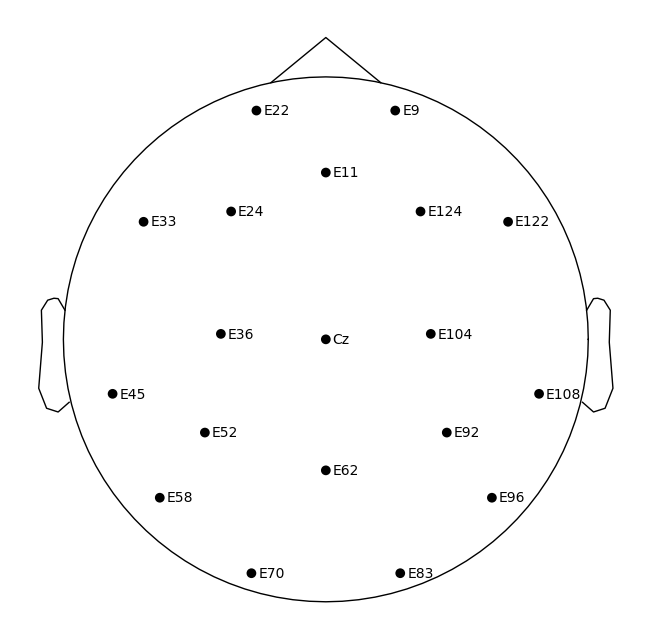

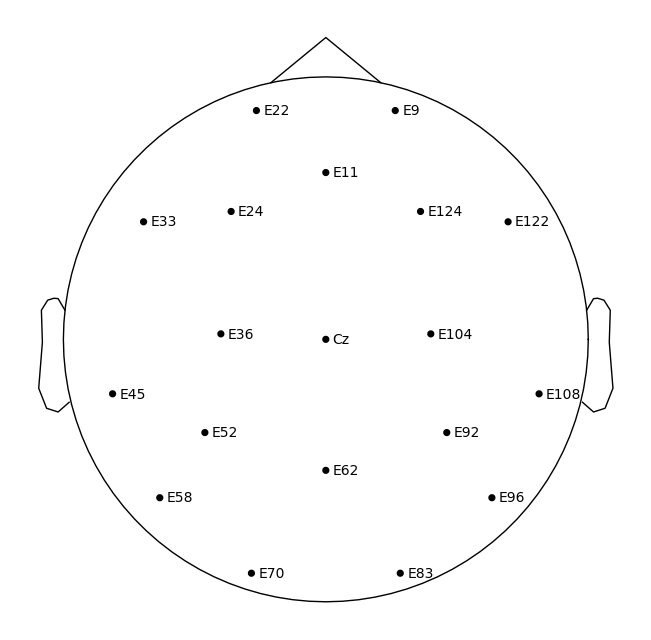

In [148]:
transformation_matrix = np.asarray([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])
hbn_montage = HBN_EC.get_montage()
print(HBN_EC.get_montage())
hbn_montage.apply_trans(mne.transforms.Transform(fro='head', to='unknown', trans=transformation_matrix))
print(hbn_montage.get_positions())
hbn_montage.plot(show_names=True, sphere=0.095)

In [149]:
for k, v in HBN_EC.info.items():
	print(k, v)

acq_pars None
acq_stim None
ctf_head_t None
description None
dev_ctf_t None
dig [<DigPoint |        LPA : (-86.0, 0.0, 0.0) mm      : head frame>, <DigPoint |     Nasion : (0.0, 86.0, 0.0) mm       : head frame>, <DigPoint |        RPA : (86.0, 0.0, 0.0) mm       : head frame>, <DigPoint |     EEG #1 : (27.0, 88.8, 10.9) mm     : head frame>, <DigPoint |     EEG #2 : (0.0, 79.6, 50.4) mm      : head frame>, <DigPoint |     EEG #3 : (-27.0, 88.8, 10.9) mm    : head frame>, <DigPoint |     EEG #4 : (-44.6, 60.2, 43.7) mm    : head frame>, <DigPoint |     EEG #5 : (-64.0, 41.3, -3.6) mm    : head frame>, <DigPoint |     EEG #6 : (-54.8, 2.8, 63.8) mm     : head frame>, <DigPoint |     EEG #7 : (-73.0, -18.7, -6.3) mm   : head frame>, <DigPoint |     EEG #8 : (-58.3, -44.9, 49.6) mm   : head frame>, <DigPoint |     EEG #9 : (-60.3, -57.6, 0.5) mm    : head frame>, <DigPoint |    EEG #10 : (0.0, -66.8, 64.7) mm     : head frame>, <DigPoint |    EEG #11 : (-27.4, -86.1, 2.4) mm    : head fra

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")
from Preprocessing.preprocessingPipeline import simplePipeline

In [14]:
bids_path = BIDSPath(root="~/mycontainer/ds004186-download", subject="NDARAA075AMK", datatype="eeg", suffix="eeg", extension=".set", task="EC")
ELECTRODES = [f'E{i}' for i in range(1, 129)]
TO_DROP = [electrode for electrode in ELECTRODES if electrode not in HBN_ELECTRODE_MAP.values()]
HBN_ELECTRODE_MAP_REVERSED = dict((v,k) for k,v in HBN_ELECTRODE_MAP.items())
task_all_data = []
runs = [1, 2, 3, 4, 5]
indices = None
for run in runs:
	try:
		bids_path.update(run=run)		
		raw = read_raw_bids(bids_path, extra_params={'preload':True}, verbose=False)
		raw.drop_channels(TO_DROP)
		mapping = {ch: 'eeg' for ch in raw.ch_names}
		raw.set_channel_types(mapping)
		raw.rename_channels(HBN_ELECTRODE_MAP_REVERSED)
		if indices is None:
			indices = raw.ch_names
		task_all_data.append(raw)

	except Exception as e:
		print(e)
concatenated_raw = mne.concatenate_raws(task_all_data)

mapping = {ch: 'eeg' for ch in concatenated_raw.ch_names}
concatenated_raw.set_channel_types(mapping)

annotations_to_drop = [i for i in range(len(concatenated_raw.annotations))]
concatenated_raw.annotations.delete(annotations_to_drop)

epochs = simplePipeline(concatenated_raw)

Not setting metadata
3 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 3 events and 30000 original time points ...
0 bad epochs dropped
((), (), ())


In [11]:
print(concatenated_raw.annotations)
print(len(concatenated_raw.annotations))

<Annotations | 8 segments: BAD boundary (4), EDGE boundary (4)>
8


In [10]:
for annotation in concatenated_raw.annotations:
	print(annotation)

OrderedDict([('onset', 39.996), ('duration', 0.0), ('description', 'BAD boundary'), ('orig_time', None)])
OrderedDict([('onset', 39.996), ('duration', 0.0), ('description', 'EDGE boundary'), ('orig_time', None)])
OrderedDict([('onset', 79.992), ('duration', 0.0), ('description', 'BAD boundary'), ('orig_time', None)])
OrderedDict([('onset', 79.992), ('duration', 0.0), ('description', 'EDGE boundary'), ('orig_time', None)])
OrderedDict([('onset', 119.988), ('duration', 0.0), ('description', 'BAD boundary'), ('orig_time', None)])
OrderedDict([('onset', 119.988), ('duration', 0.0), ('description', 'EDGE boundary'), ('orig_time', None)])
OrderedDict([('onset', 159.984), ('duration', 0.0), ('description', 'BAD boundary'), ('orig_time', None)])
OrderedDict([('onset', 159.984), ('duration', 0.0), ('description', 'EDGE boundary'), ('orig_time', None)])


In [17]:
bids_path = BIDSPath(root="~/mycontainer/ds004186-download", datatype="eeg", suffix="eeg", extension=".set")
subjects = sorted(set([bp.subject for bp in bids_path.match()]))

KeyboardInterrupt: 

In [1]:
subfolders = [f.path for f in os.scandir("/home/azureuser/mycontainer/ds004186-download") if f.is_dir() ]
print(len(subfolders))
subfolders = subfolders[2:]
print(len(subfolders))
print(subfolders[0:5])

2953
2951
['/home/azureuser/mycontainer/ds004186-download/sub-NDARAA075AMK', '/home/azureuser/mycontainer/ds004186-download/sub-NDARAA117NEJ', '/home/azureuser/mycontainer/ds004186-download/sub-NDARAA396TWZ', '/home/azureuser/mycontainer/ds004186-download/sub-NDARAA773LUW', '/home/azureuser/mycontainer/ds004186-download/sub-NDARAA947ZG5']


In [2]:
subjects = [x.split("/")[-1][4:] for x in subfolders]
print(len(subjects))
print(subjects[0:5])

2951
['NDARAA075AMK', 'NDARAA117NEJ', 'NDARAA396TWZ', 'NDARAA773LUW', 'NDARAA947ZG5']


In [3]:
tasks = ["EC", "EO"]
runs = [1, 2, 3, 4, 5]
from tqdm import tqdm

In [31]:
for subject in tqdm(subjects):
	for task in tasks:
		for run in runs:
			bids_path.update(subject=subject, task=task, run=run)
			raw = read_raw_bids(bids_path, extra_params={'preload':True}, verbose=False)

  1%|██████▏                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      | 19/2951 [05:52<15:05:50, 18.54s/it]


KeyboardInterrupt: 

In [ ]:
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
from mne_bids import BIDSPath, read_raw_bids
import warnings
warnings.filterwarnings("ignore")

bids_path = BIDSPath(root="~/mycontainer/ds004186-download", datatype="eeg", suffix="eeg", extension=".set")

def process_subject_task_run(subject, task, run, bids_path):
    bids_path.update(subject=subject, task=task, run=run)
    raw = read_raw_bids(bids_path, extra_params={'preload': False}, verbose=False)

# Assuming subjects, tasks, runs, bids_path, and to_drop are already defined
with ThreadPoolExecutor(max_workers=32) as executor:
    futures = []
    for subject in subjects:
        for task in tasks:
            for run in runs:
                futures.append(executor.submit(process_subject_task_run, subject, task, run, bids_path))
    for future in tqdm(futures):
        future.result()

 44%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      | 12976/29510 [53:16<1:07:52,  4.06it/s]


In [16]:
import os
import pandas as pd


mean_dfs = []
std_dfs = []
directory = os.path.join("/home/azureuser/mycontainer/HBN-Processed")
for root,dirs,files in os.walk(directory):
	for file in files:
		if file.endswith(".csv"):
			df = pd.read_csv(os.path.join(root, file))
			if "mean" in file:
				print(file, df.shape)
				mean_dfs.append(df)
			if "std" in file:
				std_dfs.append(df)



EOEC_means.csv (19, 2952)
agg_mean.csv (19, 1695)
ds005505-download_mean.csv (19, 137)
ds005506-download_mean.csv (19, 90)
ds005507-download_mean.csv (19, 43)
ds005508-download_mean.csv (19, 325)
ds005509-download_mean.csv (19, 87)
ds005510-download_mean.csv (19, 136)
ds005511-download_mean.csv (19, 369)
ds005512-download_mean.csv (19, 230)
ds005514-download_mean.csv (19, 277)


In [11]:
# Concatenate dfs

agg_mean_df = pd.concat(mean_dfs, axis=1)
agg_std_df = pd.concat(std_dfs, axis=1)

print(agg_mean_df.shape, agg_std_df.shape)

#agg_mean_df.to_csv("/home/azureuser/mycontainer/HBN-Processed/agg_mean.csv", index=True)
#agg_std_df.to_csv("/home/azureuser/mycontainer/HBN-Processed/agg_std.csv", index=True)

(19, 6341) (19, 6341)


In [12]:
all_subjects = []
for dataset in os.listdir("/home/azureuser/mycontainer/eegdata"):
	dataset_folder = os.path.join("/home/azureuser/mycontainer/eegdata", dataset)
	subfolders = [f.path for f in os.scandir(dataset_folder) if f.is_dir() ]
	subjects = [x.split("/")[-1][4:] for x in subfolders]
	all_subjects += subjects

In [13]:
print(len(all_subjects))

2210


In [14]:
missing_subjects = []

for subject in all_subjects:
	if subject not in agg_mean_df.columns:
		missing_subjects.append(subject)

print(len(missing_subjects))

46


In [6]:
actual_missing_subjects = []
for subject in missing_subjects:
	if subject.startswith("ND"):
		print(subject)

NDARDM385EK2
NDARNU497GTX
NDARAC857HDB
NDARAJ689BVN
NDARAX358NB5
NDARBK638HLZ
NDARBN365EV3
NDARFB322DRA
NDARFG568PXZ
NDARFH018DLG
NDARHD931FNA
NDARHT829KKB
NDARLB162XP2
NDARLD978JVJ
NDARMV981GZ7
NDARRU399NYG
NDARRY538NE1
NDARRZ927VC3
NDARTK357VHL
NDARUD776KFT
NDARBA381JGH
NDARUJ292JXV
NDARAA306NT2
NDARAA504CRN
NDARAM197GFY
NDARAN524ZK6
NDARAP739AUP
NDARBB995GGY


In [17]:

import pickle

In [10]:

with open('missing_subjects.pkl', 'wb') as fp:
    pickle.dump(actual_missing_subjects, fp)

In [26]:
with open('Preprocessing/missing_subjects.pkl', 'rb') as fp:
	missing_subjects = pickle.load(fp)

print(len(missing_subjects))

507


In [27]:
for subject in missing_subjects:
	subject_dir = os.path.join("/home/azureuser/mycontainer/HBN-Processed", f"{subject}")
	if os.path.isdir(subject_dir):
		print(os.listdir(os.path.join(subject_dir, 'epochs')))

['DespicableMe.fif', 'DiaryOfAWimpyKid.fif', 'EC.fif', 'EO.fif', 'FunwithFractals.fif', 'RestingState.fif', 'ThePresent.fif', 'contrastChangeDetection-1.fif', 'contrastChangeDetection-2.fif', 'contrastChangeDetection-3.fif', 'seqLearning8target.fif', 'surroundSupp-1.fif', 'surroundSupp-2.fif', 'symbolSearch.fif']
['DespicableMe.fif', 'DiaryOfAWimpyKid.fif', 'EC.fif', 'EO.fif', 'FunwithFractals.fif', 'RestingState.fif', 'ThePresent.fif', 'seqLearning8target.fif', 'symbolSearch.fif']
['DespicableMe.fif', 'DiaryOfAWimpyKid.fif', 'EC.fif', 'EO.fif', 'FunwithFractals.fif', 'RestingState.fif', 'ThePresent.fif', 'contrastChangeDetection-1.fif', 'contrastChangeDetection-2.fif', 'contrastChangeDetection-3.fif', 'seqLearning6target.fif', 'surroundSupp-1.fif', 'surroundSupp-2.fif', 'symbolSearch.fif']
['EC.fif', 'EO.fif', 'RestingState.fif', 'contrastChangeDetection-1.fif', 'seqLearning8target.fif', 'surroundSupp-1.fif', 'symbolSearch.fif']
['DespicableMe.fif', 'DiaryOfAWimpyKid.fif', 'EC.fif', '

In [1]:
from mne_bids import BIDSPath, read_raw_bids

bids_path = BIDSPath(root="~/mycontainer/TUH_BIDS_Converted", subject="aaaaahhh", session="s0012008", processing="02tcple", recording="t000", task="rest", datatype="eeg", suffix="eeg", extension=".edf")
TUH_patient = read_raw_bids(bids_path, verbose=True)

Extracting EDF parameters from /home/azureuser/mycontainer/TUH_BIDS_Converted/sub-aaaaahhh/ses-s0012008/eeg/sub-aaaaahhh_ses-s0012008_task-rest_proc-02tcple_rec-t000_eeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading channel info from /home/azureuser/mycontainer/TUH_BIDS_Converted/sub-aaaaahhh/ses-s0012008/eeg/sub-aaaaahhh_ses-s0012008_task-rest_proc-02tcple_rec-t000_channels.tsv.
Reading electrode coords from /home/azureuser/mycontainer/TUH_BIDS_Converted/sub-aaaaahhh/ses-s0012008/eeg/sub-aaaaahhh_ses-s0012008_space-CapTrak_electrodes.tsv.
Not fully anonymizing info - keeping his_id, sex, and hand info


In [2]:
print(TUH_patient.ch_names)
print(len(TUH_patient.ch_names))

['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'A1', 'A2', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
21


In [3]:
subfolders = [f.path for f in os.scandir("/home/azureuser/mycontainer/TUH_BIDS_Converted") if f.is_dir() ]
subjects = [x.split("/")[-1][4:] for x in subfolders]
print(f"Found {len(subjects)} subjects")


Found 14987 subjects


In [7]:
import sys
sys.path.append('/home/azureuser/mycontainer/Preprocessing')

In [9]:
from Preprocessing.preprocessingPipeline import simplePipeline
from Preprocessing.TUHProcessingJob import _process_subject 

ModuleNotFoundError: No module named 'preprocessingPipeline'